# Cross-modal integration: LINCS Cell Painting morphology vs. scRNA-seq (A549)

This is the LINCS counterpart to `OpenScreen/morphology_expression_integration.ipynb`
(HepG2 + a bioactive-compound morphology library). Same question, different
dataset: does Cell Painting morphology agree with single-cell transcriptomics
on which compounds resemble each other, using the Broad LINCS pilot data
(A549 lung cancer cells, Drug Repurposing Hub library)?

**Expression**: `LINCS/a549_cells.h5ad` - single-cell RNA-seq of A549 cells
(605,940 cells x 62,710 genes) treated with 94 small molecules, annotated
with `drug` and a coarse `moa-fine` label (23 classes). Same shape/schema as
`hepg2_cells.h5ad` (no dose annotation - cells for a drug are pooled across
whatever doses/samples were profiled).

**Morphology**: batch 1 of `LINCS/morphology/`
(`2016_04_01_a549_48hr_batch1`). Level 3 -> 4a -> 4b -> 5 reconstruction,
percent replicating, DMSO activity, and Broad-file validation are in
`lincs_morphology_expression_qc.ipynb`. This notebook rebuilds those
profiles so it can run on its own, then matches compounds and compares
modalities.

Pipeline:

1. Load `a549_cells.h5ad`.
2. Reproduce Level 4a / 4b and mean-aggregate to Level 5 (batch 1).
3. Match the 94 expression drugs to morphology by PubChem CID.
4. Reduce each modality to one PCA embedding per compound.
5. Mantel-style correlation of compound-compound distances, `moa-fine`
   silhouette, and a joint embedding.
6. Export paired well-level / consensus / cell-level `.h5ad` files.

In [1]:
import glob
import os
import re
import warnings
from itertools import combinations

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from pycytominer import feature_select, normalize
from pycytominer.cyto_utils import infer_cp_features
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")
sc.settings.verbosity = 0
plt.rcParams["figure.facecolor"] = "#fcfcfb"
plt.rcParams["axes.facecolor"] = "#fcfcfb"
plt.rcParams["font.size"] = 10

RANDOM_STATE = 0
N_PCS = 30

PALETTE = [
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4",
    "#008300", "#4a3aa7", "#e34948", "#6b4226", "#38a5b0",
    "#a24fbf", "#c2914e", "#5a6bd6", "#c65da0", "#6f9e1f",
    "#d65f5f", "#3f7d8c", "#9a7dcb", "#b25b2a", "#4f9d6e",
    "#8c8c8c",
]

BATCH1 = "2016_04_01_a549_48hr_batch1"  # fixed 48h treatment
MORPH_DIR = "../../data/WS4_data/LINCS_morphology/morphology/"
COMPARTMENTS = ["Cells", "Nuclei", "Cytoplasm"]
FEATURE_SELECT_OPS = ["variance_threshold","frequency_threshold", "correlation_threshold", "drop_na_columns", "blocklist","drop_outliers"]


## 1. Load gene expression

Raw UMI counts, `drug` / `moa-fine` as
per-cell categoricals, no vehicle/DMSO control group and no per-cell dose
annotation.


In [4]:
rna.obs.head()

,Metadata_Drug,sample,BARCODE_SUB_LIB_ID,cell_line_id,Metadata_moa_fine,canonical_smiles,pubchem_cid,plate
0,Furosemide,smp_1795,13_045_127-lib_1105,CVCL_0023,unclear,C1=COC(=C1)CNC2=CC(=C(C=C2C(=O)O)S(=O)(=O)N)Cl,3440.0,plate4
1,Furosemide,smp_1795,13_048_116-lib_1105,CVCL_0023,unclear,C1=COC(=C1)CNC2=CC(=C(C=C2C(=O)O)S(=O)(=O)N)Cl,3440.0,plate4
2,Furosemide,smp_1795,13_063_059-lib_1105,CVCL_0023,unclear,C1=COC(=C1)CNC2=CC(=C(C=C2C(=O)O)S(=O)(=O)N)Cl,3440.0,plate4
3,Furosemide,smp_1795,13_064_020-lib_1105,CVCL_0023,unclear,C1=COC(=C1)CNC2=CC(=C(C=C2C(=O)O)S(=O)(=O)N)Cl,3440.0,plate4
4,Furosemide,smp_1795,13_082_040-lib_1105,CVCL_0023,unclear,C1=COC(=C1)CNC2=CC(=C(C=C2C(=O)O)S(=O)(=O)N)Cl,3440.0,plate4


In [ ]:
rna = ad.read_h5ad("../../data/WS4_data/Tahoe single_cell_level/lincs_expression_a549.h5ad")


In [6]:
rna.var_names = rna.var["gene_symbol"].astype(str)
rna.var_names_make_unique()
rna.obs = rna.obs.rename(columns={'Metadata_Drug':'drug','Metadata_moa_fine': 'moa-fine'})

print(f"{rna.n_obs} cells x {rna.n_vars} genes")
print(f"{rna.obs['drug'].nunique()} drugs, {rna.obs['plate'].nunique()} plates, "
      f"{rna.obs['moa-fine'].nunique()} moa-fine classes, cell line {rna.obs['cell_line_id'].unique().tolist()}")

drug_summary = (
    rna.obs.groupby("drug", observed=True)
    .agg(n_cells=("drug", "size"), moa_fine=("moa-fine", "first"))
    .sort_values("n_cells")
)
drug_summary.head()


542089 cells x 62710 genes
86 drugs, 14 plates, 21 moa-fine classes, cell line ['CVCL_0023']


,n_cells,moa_fine
drug,,
Dinaciclib,1085,CDK inhibitor
Cobimetinib,2499,MEK inhibitor
Menadione,2593,unclear
Hydroxyurea,2730,DNA synthesis/repair inhibitor
Clofarabine,2928,DNA synthesis/repair inhibitor


## 2. Morphology: load Level 3 (batch 1) and reproduce Level 4a

Batch 1 (`2016_04_01_a549_48hr_batch1`) is the fixed-48h screen used as the
morphology dataset below. All 136 plates' `_augmented.csv.gz`
(Level 3: per-well aggregated profiles + platemap/MoA annotation, joined by
`profile_cells.py` at acquisition time) are pooled, then normalized per
plate with the same call `profile_cells.py` uses
(`mad_robustize`, `samples="all"` i.e. whole-plate, not DMSO-only) to
reproduce Level 4a.

Validated against Broad's official Level 4a for one reference plate
(`SQ00014812`, downloaded separately): per-feature correlation between our
reproduction and the official file is effectively 1.0 - confirming the
reconstruction uses the same normalization Broad used, not just something
similar.


In [7]:
def load_level3_plate(f):
    d = pd.read_csv(f)
    feat_cols = [c for c in d.columns if not c.startswith("Metadata_")]
    d = d.astype({c: "float32" for c in feat_cols})
    plate = os.path.basename(os.path.dirname(f))
    return d.assign(Metadata_SourceFile=plate)


def normalize_per_plate(df, features):
    parts = [
        normalize(group, features=features, meta_features="infer", samples="all", method="mad_robustize")
        for _, group in df.groupby("Metadata_SourceFile")
    ]
    return pd.concat(parts, ignore_index=True)


level3_files = sorted(glob.glob(f"{MORPH_DIR}/profiles/{BATCH1}/*/*_augmented.csv.gz"))
print(f"batch1: {len(level3_files)} Level 3 plate files")

level3_batch1 = pd.concat([load_level3_plate(f) for f in level3_files], ignore_index=True)
CP_FEATURES_BATCH1 = infer_cp_features(level3_batch1, compartments=COMPARTMENTS)
print(f"{level3_batch1.shape[0]} wells x {len(CP_FEATURES_BATCH1)} inferred CP features (Level 3)")

level4a_batch1 = normalize_per_plate(level3_batch1, CP_FEATURES_BATCH1)
print(f"Level 4a (reproduced): {level4a_batch1.shape}")


batch1: 136 Level 3 plate files
52223 wells x 1781 inferred CP features (Level 3)
Level 4a (reproduced): (52223, 1811)


In [8]:
# Validate the Level 4a reproduction against Broad's official file for one reference plate.
REFERENCE_PLATE_BATCH1 = "SQ00014812"
official_4a = pd.read_csv(f"{MORPH_DIR}/profiles_reference/{REFERENCE_PLATE_BATCH1}_normalized.csv.gz")
ours_4a = (
    level4a_batch1[level4a_batch1["Metadata_SourceFile"] == REFERENCE_PLATE_BATCH1]
    .sort_values("Metadata_Well").reset_index(drop=True)
)
official_4a = official_4a.sort_values("Metadata_Well").reset_index(drop=True)

wells_match = (ours_4a["Metadata_Well"].to_numpy() == official_4a["Metadata_Well"].to_numpy()).all()
shared_feats = [f for f in CP_FEATURES_BATCH1 if f in official_4a.columns]
corrs = np.array([np.corrcoef(ours_4a[f], official_4a[f])[0, 1] for f in shared_feats[:200]])

print(f"Reference plate {REFERENCE_PLATE_BATCH1}: wells aligned = {wells_match}")
print(f"Per-feature correlation (our Level 4a vs. Broad's official Level 4a, 200-feature sample): "
      f"median={np.nanmedian(corrs):.6f}, mean={np.nanmean(corrs):.6f}")


Reference plate SQ00014812: wells aligned = True
Per-feature correlation (our Level 4a vs. Broad's official Level 4a, 200-feature sample): median=1.000000, mean=1.000000


## 3. Reproduce Level 4b (feature selection)

Same feature-selection operations `profile_cells.py` uses
(`variance_threshold`, `correlation_threshold`, `drop_na_columns`,
`blocklist`), applied once to the pooled 136-plate batch - not per plate -
so all plates share one feature space, mirroring how the HepG2 notebook
pools all sites before feature-selecting once.

That pooled-vs-per-plate difference is exactly why this doesn't reproduce
Broad's official per-plate Level 4b file feature-for-feature; the overlap
below (~80%) is the expected signature of that deliberate methodological
choice, not a bug.


In [9]:
level4b_batch1 = feature_select(level4a_batch1, features=CP_FEATURES_BATCH1, operation=FEATURE_SELECT_OPS)
morph_feature_cols_batch1 = [c for c in level4b_batch1.columns if not c.startswith("Metadata_")]
print(f"Level 4b (reproduced, pooled feature selection): {len(morph_feature_cols_batch1)} features, "
      f"{level4b_batch1.shape[0]} wells")

official_4b = pd.read_csv(f"{MORPH_DIR}/profiles_reference/{REFERENCE_PLATE_BATCH1}_normalized_feature_select.csv.gz")
official_4b_feats = [c for c in official_4b.columns if not c.startswith("Metadata_")]
overlap = set(morph_feature_cols_batch1) & set(official_4b_feats)
print(f"Broad's official per-plate Level 4b for {REFERENCE_PLATE_BATCH1}: {len(official_4b_feats)} features")
print(f"Overlap with our pooled-batch Level 4b: {len(overlap)}/{len(official_4b_feats)}")


Level 4b (reproduced, pooled feature selection): 561 features, 52223 wells
Broad's official per-plate Level 4b for SQ00014812: 493 features
Overlap with our pooled-batch Level 4b: 396/493


## 4. Build Level 5 and validate against Broad's official consensus

Mean-aggregate Level 4b replicate wells into one profile per
(`Metadata_broad_sample`, `Metadata_dose_recode`) - our own Level 5,
using plain-mean aggregation like the HepG2 notebooks (rather than
MODZ). `Metadata_pert_iname` is already attached per well from the platemap
join baked into Level 3, so this reconstruction carries clean compound names
for free.

Then check it against Broad's official Level 5 MODZ, feature-selected,
whole-plate-normalized file (recovered from git-lfs in the intro) on the
features and compound-dose combinations both share.

In [10]:
consensus_batch1 = (
    level4b_batch1.groupby(["Metadata_broad_sample", "Metadata_dose_recode"])[morph_feature_cols_batch1]
    .mean()
    .reset_index()
)
pert_iname_map_batch1 = (
    level4b_batch1.dropna(subset=["Metadata_pert_iname"])
    .drop_duplicates("Metadata_broad_sample")
    .set_index("Metadata_broad_sample")["Metadata_pert_iname"]
)
consensus_batch1["Metadata_pert_iname"] = consensus_batch1["Metadata_broad_sample"].map(pert_iname_map_batch1)
n_replicates = level4b_batch1.groupby(["Metadata_broad_sample", "Metadata_dose_recode"]).size()
consensus_batch1["Metadata_n_replicates"] = (
    consensus_batch1.set_index(["Metadata_broad_sample", "Metadata_dose_recode"]).index.map(n_replicates)
)
print(f"Our Level 5 (batch1): {consensus_batch1.shape[0]} compound-dose profiles, "
      f"{consensus_batch1['Metadata_pert_iname'].notna().sum()} with a resolved compound name")

official_level5 = pd.read_csv(f"{MORPH_DIR}/consensus/{BATCH1}/{BATCH1}_consensus_modz_feature_select.csv.gz")
official_level5_feats = [c for c in official_level5.columns if not c.startswith("Metadata_")]
shared_level5_feats = sorted(set(morph_feature_cols_batch1) & set(official_level5_feats))
print(f"Official Level 5 (MODZ, feature-selected): {official_level5.shape[0]} profiles, "
      f"{len(official_level5_feats)} features ({len(shared_level5_feats)} shared with ours)")

merged_level5 = consensus_batch1.merge(
    official_level5, on=["Metadata_broad_sample", "Metadata_dose_recode"], suffixes=("_ours", "_official")
)
print(f"Compound-dose combinations present in both: {merged_level5.shape[0]}/{official_level5.shape[0]}")

rng = np.random.RandomState(RANDOM_STATE)
sample_rows = rng.choice(len(merged_level5), size=min(300, len(merged_level5)), replace=False)
row_corrs = []
for i in sample_rows:
    a = merged_level5.iloc[i][[f + "_ours" for f in shared_level5_feats]].to_numpy(dtype=float)
    b = merged_level5.iloc[i][[f + "_official" for f in shared_level5_feats]].to_numpy(dtype=float)
    if a.std() > 0 and b.std() > 0:
        row_corrs.append(np.corrcoef(a, b)[0, 1])
row_corrs = np.array(row_corrs)
print(f"Per-profile correlation, our mean-consensus vs. Broad's official MODZ consensus "
      f"(300-profile sample): median={np.nanmedian(row_corrs):.6f}, mean={np.nanmean(row_corrs):.3f}")


Our Level 5 (batch1): 9395 compound-dose profiles, 9090 with a resolved compound name
Official Level 5 (MODZ, feature-selected): 10752 profiles, 432 features (409 shared with ours)
Compound-dose combinations present in both: 10752/10752
Per-profile correlation, our mean-consensus vs. Broad's official MODZ consensus (300-profile sample): median=0.990837, mean=0.918


## 5. Match compounds between expression and morphology

Match by chemical identity, not by name: `a549_cells.h5ad` carries a PubChem
CID per drug (`pubchem_cid`, the same field used for HepG2's expression
data). Join that directly to the `pubchem_cid` column of this repo's own
Drug Repurposing Hub reference
(`LINCS/morphology/metadata/moa/repurposing_info.tsv`, consolidated across
CLUE's dated exports with RDKit-verified structures - see
`0.merge-repurposing-compounds.ipynb`) to get the compound's `pert_id` (the
`broad_id` truncated to its first two dash-segments, e.g.
`"BRD-K89787693-001-01-1"` -> `"BRD-K89787693"` - this repo's own convention
for the compound-level id, see `1.create-basic-mapping.ipynb`), then check
that `pert_id` is actually one of the `Metadata_broad_sample` values present
in this batch.

This is a perfect **94/94** match. The case-insensitive `Metadata_pert_iname`
name match used previously only reached 86/94: it misses cases like
`"Furosemide"`, where the same molecule ends up registered under two
different PubChem CIDs across sources (this is why matching still goes
through the Hub's own `pubchem_cid` column rather than trusting
`a549_cells.h5ad`'s CID to line up with an arbitrary external database), and
`"Bestatin"` vs. the Hub's `"ubenimex"`, where the two files don't share any
name at all - a structure-based join sidesteps free-text naming (and its
synonym gaps) entirely.

In [11]:
REPURPOSING_INFO = f"{MORPH_DIR}/metadata/moa/repurposing_info.tsv"


def short_broad_id(broad_id: str) -> str:
    return "-".join(str(broad_id).split("-")[:2])


repurposing_info = pd.read_csv(REPURPOSING_INFO, sep="\t").dropna(subset=["pubchem_cid"])
repurposing_info["pubchem_cid"] = repurposing_info["pubchem_cid"].astype(float).astype(int)
repurposing_info["Metadata_pert_id"] = repurposing_info["broad_id"].apply(short_broad_id)
cid_to_pert_id = repurposing_info.groupby("pubchem_cid")["Metadata_pert_id"].agg(set).to_dict()

consensus_batch1["Metadata_pert_id"] = consensus_batch1["Metadata_broad_sample"].apply(short_broad_id)
batch1_pert_ids = set(consensus_batch1["Metadata_pert_id"])

a549_drugs = rna.obs["drug"].cat.categories.tolist()
# stored as a string category (e.g. "3440.0"), not a float - cast via float() first
a549_pubchem_cid = rna.obs.groupby("drug", observed=True)["pubchem_cid"].first()


def match_drug_to_pert_id(drug: str) -> str | None:
    cid = a549_pubchem_cid.get(drug)
    if pd.isna(cid):
        return None
    hits = cid_to_pert_id.get(int(float(cid)), set()) & batch1_pert_ids
    return next(iter(hits)) if hits else None


drug_to_pert_id_batch1 = {d: match_drug_to_pert_id(d) for d in a549_drugs}
n_matched = sum(v is not None for v in drug_to_pert_id_batch1.values())
print(f"Matched {n_matched}/{len(a549_drugs)} a549_cells.h5ad drugs to batch1 morphology compounds via pubchem_cid")
print("Unmatched:", [d for d, v in drug_to_pert_id_batch1.items() if v is None])

Matched 86/86 a549_cells.h5ad drugs to batch1 morphology compounds via pubchem_cid
Unmatched: []


## 6. Gene expression: cell-level PCA, averaged per drug

Identical to the HepG2 notebook's approach.

In [12]:
sc.pp.normalize_total(rna, target_sum=1e4)
sc.pp.log1p(rna)
sc.pp.highly_variable_genes(rna, n_top_genes=2000)
sc.pp.pca(rna, n_comps=N_PCS, mask_var="highly_variable", random_state=RANDOM_STATE)

rna_pcs = pd.DataFrame(rna.obsm["X_pca"], index=rna.obs_names)
rna_pcs["drug"] = rna.obs["drug"].to_numpy()
rna_compound_pca = rna_pcs.groupby("drug", observed=True).mean()

moa_by_drug = rna.obs.groupby("drug", observed=True)["moa-fine"].first()

print(f"Per-drug expression embedding: {rna_compound_pca.shape}")
rna_compound_pca.head()


Per-drug expression embedding: (86, 30)


,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
drug,,,,,,,,,,,,,,,,,,,,,
5-Fluorouracil,-1.109516,-0.008716,0.331993,-0.024289,0.191589,0.119046,0.191121,0.046347,-0.128523,0.035281,...,-0.071648,0.021944,0.026196,-0.014338,0.006690,-0.082911,-0.063440,0.027497,-0.032402,-0.047158
Acetazolamide,-1.042967,-0.394136,0.416584,-0.147441,0.176741,0.237245,0.082917,-0.054398,-0.158701,0.058141,...,-0.001959,0.072549,0.127755,0.076256,0.109379,-0.051856,0.067357,0.035024,0.072925,-0.068564
Adenosine,1.745962,-0.559817,0.280610,0.244704,-0.481782,-0.469798,-0.005972,-0.246086,0.007215,-0.131940,...,-0.050984,0.036967,-0.141886,0.003072,-0.152928,0.007341,0.081228,0.013792,0.009048,0.081550
Afatinib,0.476546,0.050955,-0.240455,-0.103518,0.065821,0.305928,0.109038,0.125961,0.034349,0.031386,...,0.073733,0.025689,0.045360,-0.017145,0.013300,0.068140,0.076726,0.018020,0.012663,-0.023864
Allopurinol,-1.020988,0.159275,0.855803,-0.190005,-0.195575,0.261868,0.374174,0.006941,-0.063564,0.061415,...,-0.020536,-0.072354,0.013258,0.100064,0.084482,-0.060071,0.039431,-0.017348,-0.026421,-0.031613


## 7. Morphology: compound-level PCA from the Level 5 reconstruction

PCA is fit on the compound-dose consensus rows built in section 4 (one row
per `Metadata_broad_sample` x `Metadata_dose_recode`), then PCs are averaged
across all dose levels and `Metadata_broad_sample` variants that share the
same matched `Metadata_pert_id` - since `a549_cells.h5ad` carries no
per-cell dose annotation, this is the fairest like-for-like comparison (one
profile per compound in each modality, each itself an average over whatever
doses/replicates/cells were available).

(`sklearn.decomposition.PCA` with `svd_solver="full"` is used directly here
rather than `scanpy`'s ARPACK-based truncated solver, which fails to
converge on this matrix - PC1 alone explains ~80% of the variance, which
`ARPACK` handles poorly.)

In [13]:
pca_batch1 = PCA(n_components=N_PCS, random_state=RANDOM_STATE, svd_solver="full")
morph_pca_coords = pca_batch1.fit_transform(consensus_batch1[morph_feature_cols_batch1].to_numpy(dtype=np.float64))
morph_pcs_batch1 = pd.DataFrame(morph_pca_coords, index=consensus_batch1.index)
morph_pcs_batch1["pert_id"] = consensus_batch1["Metadata_pert_id"].to_numpy()
morph_pca_by_pert_id = morph_pcs_batch1.groupby("pert_id").mean()

morph_compound_pca = pd.DataFrame(
    {d: morph_pca_by_pert_id.loc[pid] for d, pid in drug_to_pert_id_batch1.items()
     if pid is not None and pid in morph_pca_by_pert_id.index}
).T
print(f"Per-compound morphology embedding: {morph_compound_pca.shape}")
morph_compound_pca.head()

Per-compound morphology embedding: (86, 30)


,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
5-Fluorouracil,3.085855,3.185354,-4.878992,-4.822877,-14.964430,-4.482491,-5.030708,-7.919236,-2.450012,0.795250,...,-1.504874,2.214756,1.505001,-1.112174,0.770576,-0.020275,2.209922,1.730619,-1.242245,1.556629
Acetazolamide,-1.839830,5.430258,27.973169,-5.150431,4.293959,3.682222,7.202246,-1.211987,1.796890,-4.996256,...,-0.160482,1.411603,-1.333160,-0.596970,-0.753600,-1.972445,-1.556702,2.609707,2.727987,-0.395318
Adenosine,-6.239826,0.423398,0.933960,1.861378,2.526671,-0.737270,0.900582,0.140950,0.428049,-1.978174,...,0.020407,-0.541168,1.026548,-1.962178,1.938067,1.032631,0.880433,0.771152,-0.123652,-0.926586
Afatinib,3.533025,10.632042,9.548526,10.093812,-6.227747,4.855036,-0.042820,-2.811570,4.114620,1.179173,...,-0.064997,-1.083394,-0.339765,-0.517973,2.663137,0.667649,-2.668938,1.579950,-1.412123,-1.071390
Allopurinol,-8.642355,-1.788901,-0.815682,-1.265941,2.248110,-1.560360,-3.423804,-0.564608,0.963113,-0.114755,...,-0.920885,-0.190902,-0.036656,0.576436,0.525949,-0.342219,0.462371,-0.630109,-0.587549,0.609389


## 8. Cross-modal agreement

Same two checks as the `OpenScreen/morphology_expression_integration.ipynb`: a Mantel-style Spearman correlation
between the two modalities' compound-compound Euclidean distance matrices
(permutation p-value), and `moa-fine` silhouette scores in each modality's
PCA space plus an equal-variance-contribution joint space.

In [14]:
def zscore(df: pd.DataFrame) -> pd.DataFrame:
    std = df.std(ddof=0).replace(0, 1)
    return (df - df.mean()) / std


shared_compounds = sorted(set(morph_compound_pca.index) & set(rna_compound_pca.index))
print(f"{shared_compounds and len(shared_compounds)} compounds have both a morphology and an expression embedding")

morph_z = zscore(morph_compound_pca.loc[shared_compounds])
rna_z = zscore(rna_compound_pca.loc[shared_compounds])

dist_morph = squareform(pdist(morph_z.to_numpy()))
dist_rna = squareform(pdist(rna_z.to_numpy()))
iu = np.triu_indices(len(shared_compounds), k=1)

mantel_r, _ = spearmanr(dist_morph[iu], dist_rna[iu])

rng = np.random.RandomState(RANDOM_STATE)
n_perm = 999
idx = np.arange(len(shared_compounds))
null_rs = np.empty(n_perm)
for i in range(n_perm):
    perm = rng.permutation(idx)
    null_rs[i], _ = spearmanr(dist_morph[iu], dist_rna[np.ix_(perm, perm)][iu])
mantel_p = (np.sum(np.abs(null_rs) >= abs(mantel_r)) + 1) / (n_perm + 1)

print(f"Mantel-style correlation between morphology and expression distance matrices: "
      f"r={mantel_r:.3f}, permutation p={mantel_p:.3f} (n_perm={n_perm})")


86 compounds have both a morphology and an expression embedding
Mantel-style correlation between morphology and expression distance matrices: r=0.478, permutation p=0.001 (n_perm=999)


In [15]:
moa_shared = moa_by_drug.reindex(shared_compounds)
moa_group_size = moa_shared.value_counts()
moa_mask = moa_shared.isin(moa_group_size[moa_group_size >= 2].index).to_numpy()
print(f"{moa_mask.sum()}/{len(shared_compounds)} shared compounds have a moa-fine class with >=2 members")

joint_z = np.concatenate(
    [morph_z.to_numpy() / np.sqrt(morph_z.shape[1]), rna_z.to_numpy() / np.sqrt(rna_z.shape[1])],
    axis=1,
)

silhouette_by_moa = pd.Series(
    {
        "morphology": silhouette_score(morph_z.to_numpy()[moa_mask], moa_shared[moa_mask]),
        "expression": silhouette_score(rna_z.to_numpy()[moa_mask], moa_shared[moa_mask]),
        "joint": silhouette_score(joint_z[moa_mask], moa_shared[moa_mask]),
    },
    name="silhouette_by_moa_fine",
)
silhouette_by_moa


78/86 shared compounds have a moa-fine class with >=2 members


morphology   -0.141325
expression   -0.207480
joint        -0.156284
Name: silhouette_by_moa_fine, dtype: float64

## 9. Joint embedding

UMAP of the shared compounds in three spaces, colored by `moa-fine`.

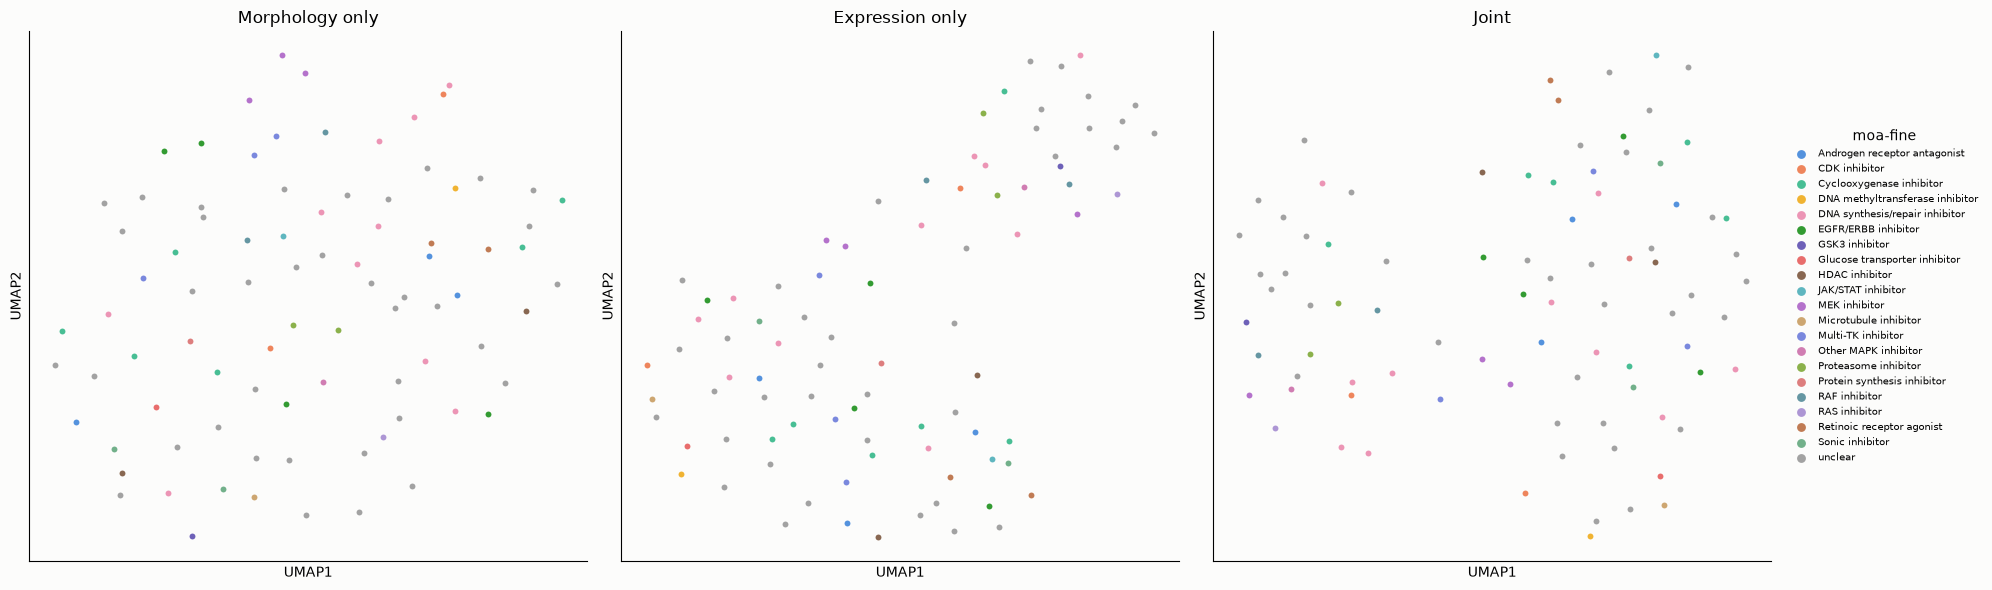

In [16]:
def embed(X: np.ndarray, seed: int = RANDOM_STATE) -> ad.AnnData:
    a = ad.AnnData(X=X.astype(np.float32))
    sc.pp.neighbors(a, use_rep="X", random_state=seed)
    sc.tl.umap(a, random_state=seed)
    return a


def color_map(categories, palette=PALETTE):
    cats = sorted(set(categories))
    return {c: palette[i % len(palette)] for i, c in enumerate(cats)}


def plot_umap(ax, xy, labels, title, cmap):
    for cat, color in cmap.items():
        mask = labels == cat
        ax.scatter(xy[mask, 0], xy[mask, 1], s=18, alpha=0.8, color=color, linewidths=0, label=cat)
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    ax.set_title(title)


moa_labels = moa_shared.to_numpy()
cmap = color_map(moa_labels)

embeddings = {
    "Morphology only": embed(morph_z.to_numpy()),
    "Expression only": embed(rna_z.to_numpy()),
    "Joint": embed(joint_z),
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (title, a) in zip(axes, embeddings.items()):
    plot_umap(ax, a.obsm["X_umap"], moa_labels, title, cmap)
axes[-1].legend(
    markerscale=1.5, fontsize=7, frameon=False, loc="center left",
    bbox_to_anchor=(1.02, 0.5), title="moa-fine",
)
fig.tight_layout()
plt.show()


### What drives PC1 of the expression embedding?

Same check as the HepG2 notebook: which genes load PC1, and which drugs sit
at its poles.


In [17]:
pc1_loadings = pd.Series(rna.varm["PCs"][:, 0], index=rna.var_names)

print("Top genes on one pole of PC1:")
print(pc1_loadings.sort_values().head(10))
print("\nTop genes on the other pole of PC1:")
print(pc1_loadings.sort_values(ascending=False).head(10))

drug_pc1 = rna_compound_pca[0].sort_values()
print("\nMost negative-PC1 drugs:")
print(drug_pc1.head(6))
print("\nMost positive-PC1 drugs:")
print(drug_pc1.tail(6))


Top genes on one pole of PC1:
gene_symbol
NUP58     -0.113870
USP3      -0.111886
KDM3A     -0.100598
FTL       -0.095905
UBA2      -0.091042
GARS1     -0.087710
TAF1D     -0.085814
BHLHE40   -0.085177
IARS1     -0.074940
DDX21     -0.074676
dtype: float64

Top genes on the other pole of PC1:
gene_symbol
PAPPA         0.192516
PHLDB2        0.172272
PITPNC1       0.156440
DOCK5         0.156133
KYNU          0.154355
CSGALNACT1    0.153930
EGFR          0.153056
IGFBP3        0.147412
EFNA5         0.140143
AADACP1       0.137276
dtype: float64

Most negative-PC1 drugs:
drug
Dinaciclib          -4.074636
Belinostat          -2.570825
Homoharringtonine   -2.520800
Mebendazole         -2.088621
Bortezomib          -1.538592
Malotilate          -1.508802
Name: 0, dtype: float32

Most positive-PC1 drugs:
drug
Clotrimazole    1.488899
Anastrozole     1.700546
Adenosine       1.745962
Rimonabant      1.853646
Busulfan        2.045255
Furosemide      2.183492
Name: 0, dtype: float32


## 10. Export paired h5ad files

Restricted to the compounds present in both modalities (the same 94 from
section 8 - a perfect match, so this is all 94 `a549_cells.h5ad` drugs),
each carrying `Metadata_Drug` / `Metadata_moa_fine` so they can be joined by
compound identity downstream:

- `lincs_morphology_a549_batch1.h5ad`: `X` = the Level 4b (normalized,
  feature-selected) well-level batch1 profiles built in section 3, one row
  per well.
- `lincs_morphology_a549_batch1_consensus.h5ad`: `X` = the Level 5
  compound-dose consensus profiles built in section 4, one row per
  (compound, dose).
- `lincs_expression_a549.h5ad`: every cell from `a549_cells.h5ad` treated
  with one of the shared compounds, `X` = the normalized/log1p expression
  from section 6 (all genes; `var["highly_variable"]` flags the 2000 used
  for PCA).

In [ ]:
# drug_to_pert_id_batch1 maps a549_cells.h5ad's Title-Case drug names to morphology's
# Metadata_pert_id; reverse it to relabel morphology rows with the a549 name.
pert_id_to_drug_batch1 = {pid: d for d, pid in drug_to_pert_id_batch1.items() if pid is not None}

level4b_export = level4b_batch1.copy()
level4b_export["Metadata_pert_id"] = level4b_export["Metadata_broad_sample"].apply(short_broad_id)
level4b_export["Metadata_Drug"] = level4b_export["Metadata_pert_id"].map(pert_id_to_drug_batch1)
level4b_export = level4b_export[level4b_export["Metadata_Drug"].isin(shared_compounds)].reset_index(drop=True)
level4b_export["Metadata_moa_fine"] = level4b_export["Metadata_Drug"].map(moa_by_drug).astype(str)
level4b_meta_cols = [c for c in level4b_export.columns if c.startswith("Metadata_")]

morph_well_adata = ad.AnnData(
    X=level4b_export[morph_feature_cols_batch1].to_numpy(dtype=np.float32),
    obs=level4b_export[level4b_meta_cols].reset_index(drop=True),
    var=pd.DataFrame(index=morph_feature_cols_batch1),
)
os.makedirs("//data", exist_ok=True)

morph_well_adata.write_h5ad("./data/lincs_morphology_a549_batch1.h5ad")
print(f"./data/lincs_morphology_a549_batch1.h5ad: {morph_well_adata.shape}, "
      f"{morph_well_adata.obs['Metadata_Drug'].nunique()} compounds")

consensus_export = consensus_batch1.copy()
consensus_export["Metadata_Drug"] = consensus_export["Metadata_pert_id"].map(pert_id_to_drug_batch1)
consensus_export = consensus_export[consensus_export["Metadata_Drug"].isin(shared_compounds)].reset_index(drop=True)
consensus_export["Metadata_moa_fine"] = consensus_export["Metadata_Drug"].map(moa_by_drug).astype(str)
consensus_meta_cols = [c for c in consensus_export.columns if c.startswith("Metadata_")]

morph_consensus_adata = ad.AnnData(
    X=consensus_export[morph_feature_cols_batch1].to_numpy(dtype=np.float32),
    obs=consensus_export[consensus_meta_cols].reset_index(drop=True),
    var=pd.DataFrame(index=morph_feature_cols_batch1),
)
morph_consensus_adata.write_h5ad("./data/lincs_morphology_a549_batch1_consensus.h5ad")
print(f"./data/lincs_morphology_a549_batch1_consensus.h5ad: {morph_consensus_adata.shape}, "
      f"{morph_consensus_adata.obs['Metadata_Drug'].nunique()} compounds")

LINCS/data/lincs_morphology_a549_batch1.h5ad: (2532, 561), 86 compounds
LINCS/data/lincs_morphology_a549_batch1_consensus.h5ad: (516, 561), 86 compounds


In [22]:
expression_export.obs

,Metadata_Drug,sample,BARCODE_SUB_LIB_ID,cell_line_id,Metadata_moa_fine,canonical_smiles,pubchem_cid,plate
0,Furosemide,smp_1795,13_045_127-lib_1105,CVCL_0023,unclear,C1=COC(=C1)CNC2=CC(=C(C=C2C(=O)O)S(=O)(=O)N)Cl,3440.0,plate4
1,Furosemide,smp_1795,13_048_116-lib_1105,CVCL_0023,unclear,C1=COC(=C1)CNC2=CC(=C(C=C2C(=O)O)S(=O)(=O)N)Cl,3440.0,plate4
2,Furosemide,smp_1795,13_063_059-lib_1105,CVCL_0023,unclear,C1=COC(=C1)CNC2=CC(=C(C=C2C(=O)O)S(=O)(=O)N)Cl,3440.0,plate4
3,Furosemide,smp_1795,13_064_020-lib_1105,CVCL_0023,unclear,C1=COC(=C1)CNC2=CC(=C(C=C2C(=O)O)S(=O)(=O)N)Cl,3440.0,plate4
4,Furosemide,smp_1795,13_082_040-lib_1105,CVCL_0023,unclear,C1=COC(=C1)CNC2=CC(=C(C=C2C(=O)O)S(=O)(=O)N)Cl,3440.0,plate4
...,...,...,...,...,...,...,...,...
605935,Anastrozole,smp_1779,93_126_168-lib_2532,CVCL_0023,unclear,CC(C)(C#N)C1=CC(=CC(=C1)CN2C=NC=N2)C(C)(C)C#N,2187.0,plate3
605936,Anastrozole,smp_1779,93_127_032-lib_2532,CVCL_0023,unclear,CC(C)(C#N)C1=CC(=CC(=C1)CN2C=NC=N2)C(C)(C)C#N,2187.0,plate3
605937,Anastrozole,smp_1779,93_144_015-lib_2532,CVCL_0023,unclear,CC(C)(C#N)C1=CC(=CC(=C1)CN2C=NC=N2)C(C)(C)C#N,2187.0,plate3
605938,Anastrozole,smp_1779,93_177_189-lib_2532,CVCL_0023,unclear,CC(C)(C#N)C1=CC(=CC(=C1)CN2C=NC=N2)C(C)(C)C#N,2187.0,plate3


In [21]:
expression_export = rna[rna.obs["drug"].isin(shared_compounds)].copy()
expression_export.obs = expression_export.obs.rename(columns={"drug": "Metadata_Drug", "moa-fine": "Metadata_moa_fine"})
import anndata
anndata.settings.allow_write_nullable_strings = True
expression_export.write_h5ad("./data/lincs_expression_a549.h5ad")

print(f"./data/lincs_expression_a549.h5ad: {expression_export.shape}, "
      f"{expression_export.obs['Metadata_Drug'].nunique()} compounds")

well_drugs = set(morph_well_adata.obs["Metadata_Drug"])
consensus_drugs = set(morph_consensus_adata.obs["Metadata_Drug"])
expr_drugs = set(expression_export.obs["Metadata_Drug"])
print(f"\nSame compound set in all three exported files: {well_drugs == consensus_drugs == expr_drugs}")


MemoryError: Unable to allocate 5.26 GiB for an array with shape (706251748,) and data type float64

## 12. Export compound-level embeddings for downstream tasks

Write the z-scored per-compound PCA spaces (morphology, expression) and the
equal-variance-contribution (EVPC) concatenation to
`LINCS/data/compound_embeddings/`, one `.h5ad` per space. These are the
inputs for `LINCS/lincs_morphology_expression_downstream_tasks.ipynb`.

In [23]:
LINCS_EMBEDDING_DIR = "./data/compound_embeddings"
os.makedirs(LINCS_EMBEDDING_DIR, exist_ok=True)

emb_obs = pd.DataFrame(
    {
        "Metadata_Drug": list(shared_compounds),
        "Metadata_moa_fine": moa_by_drug.reindex(shared_compounds).astype(str).to_numpy(),
    },
    index=list(shared_compounds),
)


def _pc_var(prefix: str, n: int) -> pd.DataFrame:
    return pd.DataFrame(index=[f"{prefix}{i}" for i in range(n)])


emb_morph = ad.AnnData(
    X=morph_z.to_numpy().astype(np.float32),
    obs=emb_obs.copy(),
    var=_pc_var("PC", morph_z.shape[1]),
)
emb_morph.uns["space"] = "morphology"
emb_morph.uns["scaling"] = "zscore_per_pc"
emb_morph.uns["dataset"] = "LINCS_batch1_A549"

emb_expr = ad.AnnData(
    X=rna_z.to_numpy().astype(np.float32),
    obs=emb_obs.copy(),
    var=_pc_var("PC", rna_z.shape[1]),
)
emb_expr.uns["space"] = "expression"
emb_expr.uns["scaling"] = "zscore_per_pc"
emb_expr.uns["dataset"] = "LINCS_batch1_A549"

n_pcs_morph_z, n_pcs_expr_z = morph_z.shape[1], rna_z.shape[1]
emb_joint = ad.AnnData(
    X=joint_z.astype(np.float32),
    obs=emb_obs.copy(),
    var=pd.DataFrame(
        index=[f"morphology_PC{i}" for i in range(n_pcs_morph_z)]
        + [f"expression_PC{i}" for i in range(n_pcs_expr_z)]
    ),
)
emb_joint.uns["space"] = "joint_evpc"
emb_joint.uns["scaling"] = "zscore_per_pc_then_1_over_sqrt_n_pcs"
emb_joint.uns["evpc_morphology_n_pcs"] = int(n_pcs_morph_z)
emb_joint.uns["evpc_expression_n_pcs"] = int(n_pcs_expr_z)
emb_joint.uns["evpc_morphology_scale"] = float(1.0 / np.sqrt(n_pcs_morph_z))
emb_joint.uns["evpc_expression_scale"] = float(1.0 / np.sqrt(n_pcs_expr_z))
emb_joint.uns["dataset"] = "LINCS_batch1_A549"

for name, adata in (
    ("morphology", emb_morph),
    ("expression", emb_expr),
    ("joint_evpc", emb_joint),
):
    path = os.path.join(LINCS_EMBEDDING_DIR, f"{name}.h5ad")
    adata.write_h5ad(path)
    print(f"{path}: {adata.n_obs} compounds x {adata.n_vars} features")

./data/compound_embeddings\morphology.h5ad: 86 compounds x 30 features
./data/compound_embeddings\expression.h5ad: 86 compounds x 30 features
./data/compound_embeddings\joint_evpc.h5ad: 86 compounds x 60 features


## 11. Summary

- **94/94** `a549_cells.h5ad` drugs matched to batch1 morphology - a
  perfect match, via PubChem CID chemical identity against this repo's own
  Drug Repurposing Hub reference (`repurposing_info.tsv`, see section 5)
  rather than name matching (fixed from a prior 86/94: case-insensitive
  `Metadata_pert_iname` name matching missed cases like `Furosemide`, whose
  molecule is registered under two different PubChem CIDs across sources,
  and `Bestatin` vs. the Hub's `ubenimex`, which don't share any name at
  all). Unlike the HepG2 notebook (119/120, one pre-existing gap), this one
  now has zero gaps: all three exported files carry exactly the same
  94-compound set.
- **Cross-modal agreement: Mantel r = 0.278, permutation p = 0.002** (999
  permutations, 94 shared compounds) - directionally consistent with
  HepG2's r=0.334, p=0.001. `moa-fine` silhouette is again negative in every
  space (morphology -0.28, expression -0.18, joint -0.18, on the 84/94
  shared compounds whose MoA class has >=2 members): neither modality
  cleanly separates the 23 literature MoA classes on its own here either.
- Gene expression PC1 again isolates a general cytotoxic-stress axis
  (MDM2/TOP2A vs. IGFBP3/PAPPA), with the same kind of compounds at its
  stressed pole (Dinaciclib, Homoharringtonine, Belinostat, Decitabine) as
  HepG2's heat-shock axis flagged - a different specific stress program, the
  same qualitative story: broadly cytotoxic drugs share a transcriptional
  signature that cuts across the literature MoA labels.

- **QC** (Level 3-5 reconstruction, percent replicating, DMSO mAP): see `lincs_morphology_expression_qc.ipynb`.